In [ ]:
!pip uninstall -y transformers huggingface_hub peft accelerate bitsandbytes
!pip install -q \
  "transformers==4.57.0" \
  "huggingface_hub==0.35.3" \
  "peft==0.17.1" \
  "accelerate==1.10.1" \
  "bitsandbytes==0.47.0" \
  datasets sentencepiece safetensors

# Install other utilities
!pip install -q yfinance matplotlib seaborn scipy

print('All packages installed and configured. Please restart the Colab runtime (Runtime > Restart runtime) and then run all cells from the beginning to apply changes.')

Found existing installation: transformers 5.0.0
Uninstalling transformers-5.0.0:
  Successfully uninstalled transformers-5.0.0
Found existing installation: huggingface_hub 1.10.1
Uninstalling huggingface_hub-1.10.1:
  Successfully uninstalled huggingface_hub-1.10.1
Found existing installation: peft 0.18.1
Uninstalling peft-0.18.1:
  Successfully uninstalled peft-0.18.1
Found existing installation: accelerate 1.13.0
Uninstalling accelerate-1.13.0:
  Successfully uninstalled accelerate-1.13.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 3.8 MB/s eta 0:00:00
Reason for being yanked: Error in the setup causing installation issues
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 81.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 564.3/564.3 kB 44.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 504.9/504.9 kB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.9/374.9 kB 33.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import torch
if torch.cuda.is_available():
    name = torch.cuda.get_device_name(0)
    mem  = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'GPU      : {name}')
    print(f'VRAM     : {mem:.1f} GB')
    print(f'CUDA     : {torch.version.cuda}')
    print(f'PyTorch  : {torch.__version__}')
    print('T4 confirmed!' if 'T4' in name else 'Different GPU — still works')
else:
    print('No GPU! Go to: Runtime > Change runtime type > T4 GPU')

GPU      : Tesla T4
VRAM     : 15.6 GB
CUDA     : 12.8
PyTorch  : 2.10.0+cu128
T4 confirmed!


In [ ]:
# CELL 3 — Mount Google Drive + create folders
from google.colab import drive
import os

drive.mount('/content/drive')

BASE       = '/content/drive/MyDrive/StudentID_Assignment2'
CODES_DIR  = f'{BASE}/codes'
DATA_DIR   = f'{CODES_DIR}/data'
MODEL_DIR  = f'{DATA_DIR}/qwen-1.5b-finetuned'
REPORT_DIR = f'{BASE}/report'

for d in [BASE, CODES_DIR, DATA_DIR, MODEL_DIR, REPORT_DIR]:
    os.makedirs(d, exist_ok=True)

print('Drive mounted')
print(f'  BASE      : {BASE}')
print(f'  DATA      : {DATA_DIR}')
print(f'  MODEL SAVE: {MODEL_DIR}')

Mounted at /content/drive
Drive mounted
  BASE      : /content/drive/MyDrive/StudentID_Assignment2
  DATA      : /content/drive/MyDrive/StudentID_Assignment2/codes/data
  MODEL SAVE: /content/drive/MyDrive/StudentID_Assignment2/codes/data/qwen-1.5b-finetuned


In [ ]:
import shutil
import os

# Source (temporary Colab location)
source_path = "/content/financial_assistant_dataset.csv"

# Destination (your Drive data folder)
destination_path = f"{DATA_DIR}/financial_assistant_dataset.csv"

# Move file if it exists
if os.path.exists(source_path):
    shutil.move(source_path, destination_path)
    print(f"✅ File moved to Drive: {destination_path}")
else:
    print("⚠️ File not found in /content. Check upload or filename.")

✅ File moved to Drive: /content/drive/MyDrive/StudentID_Assignment2/codes/data/financial_assistant_dataset.csv


In [ ]:
# — All imports
import os, json, warnings
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import yfinance as yf
import requests
warnings.filterwarnings('ignore')

from datasets import Dataset
from transformers import (
    AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig,
    TrainingArguments, Trainer, DataCollatorForLanguageModeling
)
from peft import LoraConfig, get_peft_model, TaskType, prepare_model_for_kbit_training
from google.colab import files
from IPython.display import display
from datetime import datetime

MODEL_NAME = 'Qwen/Qwen2.5-1.5B-Instruct'
DEVICE     = 'cuda' if torch.cuda.is_available() else 'cpu'
CSV_PATH   = f'{DATA_DIR}/financial_assistant_dataset.csv'
MAX_LENGTH = 512

SYSTEM_PROMPT = (
    'You are an expert personal financial advisor. '
    'Give clear accurate and actionable financial advice. '
    'Always consider the user specific situation and risk tolerance.'
)

print(f'Imports OK | Device: {DEVICE} | Model: {MODEL_NAME}')

Imports OK | Device: cuda | Model: Qwen/Qwen2.5-1.5B-Instruct


In [ ]:
# CELL 5 — Load CSV directly from Google Drive
print(f'Loading dataset from: {CSV_PATH}')

if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(f"CSV not found at: {CSV_PATH}")

df = pd.read_csv(CSV_PATH)

print(f'Shape   : {df.shape}')
print(f'Columns : {df.columns.tolist()}')
print(f'Nulls   : {df.isnull().sum().to_dict()}')
display(df.head(3))

df['prompt_len'] = df['prompt'].astype(str).str.len()
df['response_len'] = df['response'].astype(str).str.len()

print(f'Avg prompt len  : {df["prompt_len"].mean():.0f} chars')
print(f'Avg response len: {df["response_len"].mean():.0f} chars')

Loading dataset from: /content/drive/MyDrive/StudentID_Assignment2/codes/data/financial_assistant_dataset.csv
Shape   : (200, 2)
Columns : ['prompt', 'response']
Nulls   : {'prompt': 0, 'response': 0}


,prompt,response
0,I earn 3000 a month and have no idea how to bu...,The 50/30/20 rule is an excellent framework fo...
1,"My family brings in 40000 a year, but we alway...","You likely have lifestyle creep, where your ex..."
2,I am a student working part-time making 800 a ...,"As a student, your primary financial goal shou..."


Avg prompt len  : 57 chars
Avg response len: 482 chars


In [ ]:
# CELL 6 — Clean + format dataset for Qwen chat template
def format_for_qwen(row):
    prompt = str(row["prompt"]).strip()
    response = str(row["response"]).strip()

    return {
        "text": (
            f"<|im_start|>system\n{SYSTEM_PROMPT}<|im_end|>\n"
            f"<|im_start|>user\n{prompt}<|im_end|>\n"
            f"<|im_start|>assistant\n{response}<|im_end|>"
        )
    }

df_clean = (
    df[["prompt", "response"]]
    .dropna()
    .drop_duplicates(subset="prompt")
    .reset_index(drop=True)
)

hf_dataset = Dataset.from_pandas(df_clean, preserve_index=False)
hf_dataset = hf_dataset.map(format_for_qwen)

split = hf_dataset.train_test_split(test_size=0.1, seed=42)
train_data = split["train"]
val_data = split["test"]

print(f"Clean  : {len(df_clean)} samples")
print(f"Train  : {len(train_data)}")
print(f"Val    : {len(val_data)}")
print("\nFormatted example:")
print(train_data[0]["text"])

Map:   0%|          | 0/108 [00:00<?, ? examples/s]

Clean  : 108 samples
Train  : 97
Val    : 11

Formatted example:
<|im_start|>system
You are an expert personal financial advisor. Give clear accurate and actionable financial advice. Always consider the user specific situation and risk tolerance.<|im_end|>
<|im_start|>user
Should I buy a house or keep renting?<|im_end|>
<|im_start|>assistant
Renting offers flexibility and caps your monthly housing costs, while buying builds equity but involves significant unrecoverable costs like maintenance, taxes, and interest. Run a rent versus buy calculator for your specific city to compare the long-term financial outcomes. Only buy if you plan to stay in the same location for at least five to seven years, as closing costs will eat any short-term equity. Ensure your total housing payment stays below 30% of your gross monthly income. Do not view a primary residence strictly as an investment.<|im_end|>


In [ ]:
# CELL 7 — Load tokenizer
print(f'Loading tokenizer: {MODEL_NAME} ...')

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True,
    padding_side='right'
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print(f'Vocab size : {tokenizer.vocab_size:,}')
print(f'EOS token  : {tokenizer.eos_token!r}')
print(f'PAD token  : {tokenizer.pad_token!r}')
print(f'PAD token ID: {tokenizer.pad_token_id}')
print(f'Max length : {tokenizer.model_max_length}')

test_text = 'How should I invest $10,000 safely?'
toks = tokenizer(test_text)
print(f'Test: "{test_text}"')
print(f'  Token count : {len(toks["input_ids"])}')
print(f'  Token IDs   : {toks["input_ids"]}')

Loading tokenizer: Qwen/Qwen2.5-1.5B-Instruct ...


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Vocab size : 151,643
EOS token  : '<|im_end|>'
PAD token  : '<|endoftext|>'
PAD token ID: 151643
Max length : 131072
Test: "How should I invest $10,000 safely?"
  Token count : 13
  Token IDs   : [4340, 1265, 358, 2725, 400, 16, 15, 11, 15, 15, 15, 21000, 30]


In [ ]:
# CELL 8 — Tokenize the dataset
def tokenize_fn(batch):
    tokens = tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH,
        padding="max_length"
    )

    labels = []
    for input_ids, attention_mask in zip(tokens["input_ids"], tokens["attention_mask"]):
        label = [
            token_id if mask == 1 else -100
            for token_id, mask in zip(input_ids, attention_mask)
        ]
        labels.append(label)

    tokens["labels"] = labels
    return tokens

drop_cols = [c for c in train_data.column_names if c in [
    "prompt", "response", "text", "prompt_len", "response_len", "__index_level_0__"
]]

print("Tokenizing...")
tok_train = train_data.map(tokenize_fn, batched=True, remove_columns=drop_cols)
tok_val = val_data.map(
    tokenize_fn,
    batched=True,
    remove_columns=[c for c in drop_cols if c in val_data.column_names]
)

tok_train.set_format("torch")
tok_val.set_format("torch")

lens = [
    len([x for x in tok_train[i]["input_ids"] if x != tokenizer.pad_token_id])
    for i in range(min(50, len(tok_train)))
]

print(f"Train: {len(tok_train)} | Val: {len(tok_val)}")
print(f"Avg token len: {np.mean(lens):.0f}  Max: {max(lens)}  Min: {min(lens)}")

Tokenizing...


Map:   0%|          | 0/97 [00:00<?, ? examples/s]

Map:   0%|          | 0/11 [00:00<?, ? examples/s]

Train: 97 | Val: 11
Avg token len: 150  Max: 170  Min: 133


In [ ]:
# CELL 9 — Load Qwen 2.5 1.5B in 4-bit quantization
print(f"Loading {MODEL_NAME} in 4-bit...")

import torch
from transformers import AutoModelForCausalLM, BitsAndBytesConfig

compute_dtype = torch.float16

bnb_cfg = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=compute_dtype,
    bnb_4bit_use_double_quant=True
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_cfg,
    device_map="auto",
    trust_remote_code=True
)

model.config.use_cache = False

total = sum(p.numel() for p in model.parameters())
print(f"Model loaded successfully")
print(f"Parameters    : {total/1e9:.2f}B")

if torch.cuda.is_available():
    print(f"VRAM used     : {torch.cuda.memory_allocated()/1e9:.2f} GB")
    print(f"VRAM reserved : {torch.cuda.memory_reserved()/1e9:.2f} GB")
else:
    print("CUDA not available")

Loading Qwen/Qwen2.5-1.5B-Instruct in 4-bit...


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Model loaded successfully
Parameters    : 0.89B
VRAM used     : 1.16 GB
VRAM reserved : 1.58 GB


In [ ]:
# CELL 10 — Apply LoRA
model = prepare_model_for_kbit_training(model)

lora_cfg = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM
)

model = get_peft_model(model, lora_cfg)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())

print("LoRA applied to Qwen 2.5 1.5B")
print(f"  Trainable : {trainable:,} ({100 * trainable / total:.2f}%)")
print(f"  Frozen    : {total - trainable:,}")
print(f"  r={lora_cfg.r}, alpha={lora_cfg.lora_alpha}")
print(f"  Modules   : {list(lora_cfg.target_modules)}")
print("Only a small fraction of parameters are trained, so this is memory-efficient.")

LoRA applied to Qwen 2.5 1.5B
  Trainable : 4,358,144 (0.49%)
  Frozen    : 888,616,448
  r=16, alpha=32
  Modules   : ['v_proj', 'o_proj', 'q_proj', 'k_proj']
Only a small fraction of parameters are trained, so this is memory-efficient.


In [ ]:
# CELL 11 — Baseline test BEFORE fine-tuning
def generate_response(prompt_text, max_new_tokens=250, temperature=0.7):
    msgs = [
        {'role':'system','content':SYSTEM_PROMPT},
        {'role':'user',  'content':prompt_text}
    ]
    text   = tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(text, return_tensors='pt').to(DEVICE)
    with torch.no_grad():
        out = model.generate(
            **inputs, max_new_tokens=max_new_tokens,
            temperature=temperature, do_sample=True,
            pad_token_id=tokenizer.pad_token_id
        )
    return tokenizer.decode(out[0][inputs['input_ids'].shape[1]:],
                            skip_special_tokens=True).strip()

test_prompts = [
    'I earn 3000 a month and have no idea how to budget. Help me start.',
    'I have 10000 in credit card debt. What should I do first?',
    'I am 22 and terrified of losing money. How should I invest?'
]

baseline = {}
print('BASELINE — before fine-tuning')
print('='*60)
for i,p in enumerate(test_prompts, 1):
    r = generate_response(p)
    baseline[p] = r
    print(f'[{i}] Q: {p}')
    print(f'    A: {r[:300]}')
    print('-'*60)
print('Baseline saved — compare in Cell 14 after training')

BASELINE — before fine-tuning
[1] Q: I earn 3000 a month and have no idea how to budget. Help me start.
    A: Starting a budget can seem overwhelming, but it's a crucial step in managing your finances effectively. Here’s a simple guide to help you get started:

1. **List Your Income**: Write down all sources of income for the past few months. You mentioned earning $3000 per month.

2. **List Your Expenses**
------------------------------------------------------------
[2] Q: I have 10000 in credit card debt. What should I do first?
    A: Dealing with high credit card debt can be overwhelming, but it's important to start addressing your debts responsibly. Here’s a step-by-step approach you might consider:

1. **Assess Your Situation**: Understand how much you owe, what you earn each month, and if there is any extra income or assets t
------------------------------------------------------------
[3] Q: I am 22 and terrified of losing money. How should I invest?
    A: It's great that you

Fine-tuning Qwen 2.5 1.5B on your financial dataset...
Watch the loss decrease over time.



Epoch,Training Loss,Validation Loss
1,2.320000,1.579113
2,1.583500,1.376530
3,1.440300,1.344683


Done! Loss=1.6874 | Steps=39


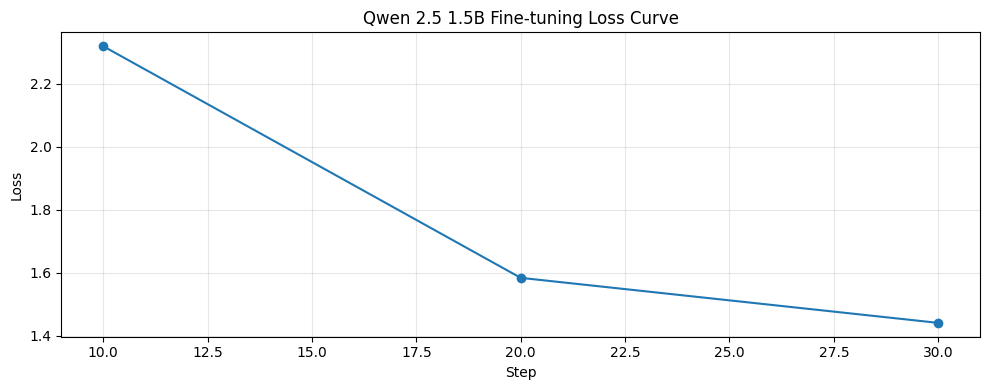

In [ ]:
# CELL 12 — Fine-tune the model
print("Fine-tuning Qwen 2.5 1.5B on your financial dataset...")
print("Watch the loss decrease over time.\n")

from transformers import TrainingArguments, Trainer, default_data_collator

train_args = TrainingArguments(
    output_dir="/content/checkpoints",
    num_train_epochs=3,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
    fp16=True,
    logging_steps=10,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    save_total_limit=1,
    warmup_ratio=0.05,
    lr_scheduler_type="cosine",
    report_to="none",
    dataloader_pin_memory=False
)

trainer = Trainer(
    model=model,
    args=train_args,
    train_dataset=tok_train,
    eval_dataset=tok_val,
    data_collator=default_data_collator
)

result = trainer.train()
print(f"Done! Loss={result.training_loss:.4f} | Steps={result.global_step}")

# Plot training loss
logs = [x for x in trainer.state.log_history if "loss" in x and "eval_loss" not in x]
if logs:
    plt.figure(figsize=(10, 4))
    plt.plot([l["step"] for l in logs], [l["loss"] for l in logs], marker="o")
    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.title("Qwen 2.5 1.5B Fine-tuning Loss Curve")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{DATA_DIR}/training_loss.png", dpi=150)
    plt.show()

In [ ]:
# CELL 13 — Save fine-tuned model to Google Drive
print(f"Saving to: {MODEL_DIR}")

model.save_pretrained(MODEL_DIR)
tokenizer.save_pretrained(MODEL_DIR)

meta = {
    "base_model": MODEL_NAME,
    "lora_r": 16,
    "lora_alpha": 32,
    "max_length": MAX_LENGTH,
    "epochs": 3,
    "lr": 2e-4,
    "train_samples": len(tok_train),
    "val_samples": len(tok_val),
    "final_loss": round(result.training_loss, 4),
    "saved_at": datetime.now().isoformat()
}

with open(f"{MODEL_DIR}/training_config.json", "w") as f:
    json.dump(meta, f, indent=2)

print("Saved LoRA adapter + tokenizer!")

for fname in sorted(os.listdir(MODEL_DIR)):
    sz = os.path.getsize(f"{MODEL_DIR}/{fname}")
    print(f"  {fname:<45} {sz/1e6:.2f} MB")

print("\nNote: This is a LoRA adapter — requires base model to load.")

Saving to: /content/drive/MyDrive/StudentID_Assignment2/codes/data/qwen-1.5b-finetuned
Saved LoRA adapter + tokenizer!
  README.md                                     0.01 MB
  adapter_config.json                           0.00 MB
  adapter_model.safetensors                     17.46 MB
  added_tokens.json                             0.00 MB
  chat_template.jinja                           0.00 MB
  merges.txt                                    1.67 MB
  special_tokens_map.json                       0.00 MB
  tokenizer.json                                11.42 MB
  tokenizer_config.json                         0.00 MB
  training_config.json                          0.00 MB
  vocab.json                                    2.78 MB

Note: This is a LoRA adapter — requires base model to load.


In [ ]:
# CELL 14 — After test + before vs after comparison
after = {}
finance_kw = ['budget','invest','save','debt','interest',
              'income','expense','fund','portfolio','risk']

print('BEFORE vs AFTER FINE-TUNING')
print('='*65)
for i,p in enumerate(test_prompts, 1):
    a = generate_response(p)
    after[p] = a
    print(f'[{i}] {p}')
    print(f'  BEFORE: {baseline[p][:250]}')
    print(f'  AFTER : {a[:250]}')
    print('-'*65)

bl  = [len(baseline[p]) for p in test_prompts]
al  = [len(after[p])    for p in test_prompts]
bkw = np.mean([sum(k in baseline[p].lower() for k in finance_kw) for p in test_prompts])
akw = np.mean([sum(k in after[p].lower()    for k in finance_kw) for p in test_prompts])
print(f'Avg length  — Before:{np.mean(bl):.0f}  After:{np.mean(al):.0f}')
print(f'Finance KW  — Before:{bkw:.1f}         After:{akw:.1f}')

BEFORE vs AFTER FINE-TUNING
[1] I earn 3000 a month and have no idea how to budget. Help me start.
  BEFORE: Starting a budget can seem overwhelming, but it's a crucial step in managing your finances effectively. Here’s a simple guide to help you get started:

1. **List Your Income**: Write down all sources of income for the past few months. You mentioned e
  AFTER : Start by writing down every single dollar that comes in and goes out for a month. This will give you a clear picture of your current spending habits. Create two separate columns, one for income and one for expenses. Track all purchases, from grocerie
-----------------------------------------------------------------
[2] I have 10000 in credit card debt. What should I do first?
  BEFORE: Dealing with high credit card debt can be overwhelming, but it's important to start addressing your debts responsibly. Here’s a step-by-step approach you might consider:

1. **Assess Your Situation**: Understand how much you owe, what you ea

In [ ]:
# CELL 15 — Zero-shot / Few-shot / Chain-of-Thought prompting
q = 'I have $5000. Pay off credit card at 18% interest or invest in stocks?'

# Zero-shot
zs = generate_response(q)
print('1) ZERO-SHOT')
print(f'   Q: {q}')
print(f'   A: {zs[:300]}')

# Few-shot
fs_prompt = (
    'Examples of good financial advice:\n'
    'Q: Save or invest $1000? A: Emergency fund first, then index funds.\n'
    'Q: High-interest debt? A: Pay it off first — guaranteed return.\n\n'
    f'Now: {q}'
)
fs = generate_response(fs_prompt)
print('\n2) FEW-SHOT (guided by 2 examples)')
print(f'   A: {fs[:300]}')

# CoT
cot_prompt = (
    f'Question: {q}\n\n'
    'Think step by step:\n'
    'Step 1: Guaranteed return from paying off 18% debt?\n'
    'Step 2: Average annual stock market return?\n'
    'Step 3: Risks of each option?\n'
    'Step 4: Best decision and why?'
)
cot = generate_response(cot_prompt, max_new_tokens=350)
print('\n3) CHAIN-OF-THOUGHT (step-by-step reasoning)')
print(f'   A: {cot[:400]}')
print('\nSummary: CoT=most structured | Few-shot=guided format | Zero-shot=baseline')

1) ZERO-SHOT
   Q: I have $5000. Pay off credit card at 18% interest or invest in stocks?
   A: Given your immediate goal of paying off high-interest debt, prioritize paying down the credit card balance as quickly as possible. Use a high-yield savings account to avoid any unnecessary fees. If you can immediately pay off the entire balance without risking losing it to overdrafts, do so. This ac

2) FEW-SHOT (guided by 2 examples)
   A: Pay down your high-interest credit card balance immediately. The minimum payment is just enough to keep you current but not nearly enough to reduce the principal. You will save thousands of dollars over time by eliminating this expense entirely. Once that is done, consider investing in a diversified

3) CHAIN-OF-THOUGHT (step-by-step reasoning)
   A: Step 1: The high-interest rate on your credit card means you'll lose money if you pay it off now.
Step 2: Stocks typically offer a higher average annual return than credit cards, but there's always some level

,ticker,price,pe_ratio,52w_high,52w_low,beta
0,AAPL,270.23,33.320595,288.62,189.81,1.109
1,MSFT,422.79,26.309273,555.45,355.67,1.107
2,GOOGL,341.68,31.061817,349.00,146.10,1.128
3,TSLA,400.62,357.696400,498.83,222.79,1.915
4,SPY,710.14,28.155151,712.38,508.46,N/A


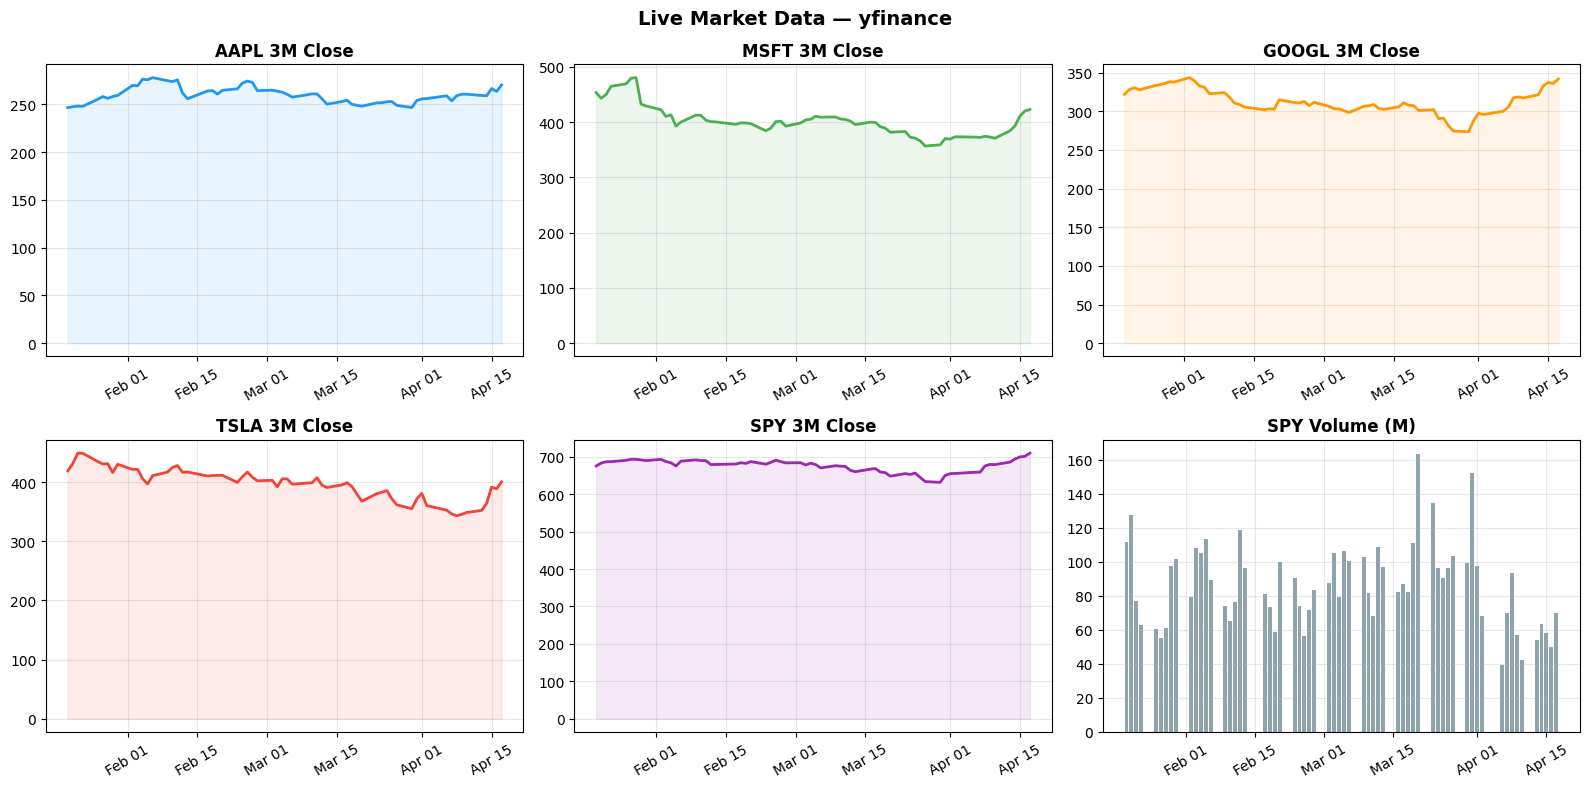

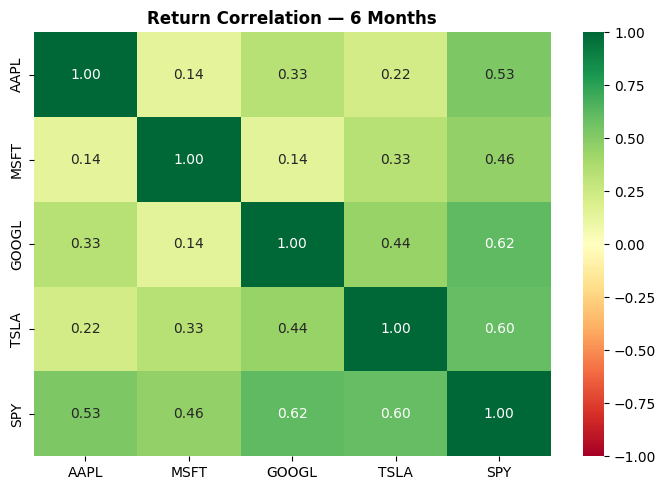

Charts saved to Drive


In [ ]:
# CELL 16 — yfinance live data + charts
TICKERS = ['AAPL','MSFT','GOOGL','TSLA','SPY']

def get_stock_info(ticker):
    try:
        info = yf.Ticker(ticker).info
        return {
            'ticker'  :ticker,
            'price'   :info.get('currentPrice', info.get('regularMarketPrice','N/A')),
            'pe_ratio':info.get('trailingPE','N/A'),
            '52w_high':info.get('fiftyTwoWeekHigh','N/A'),
            '52w_low' :info.get('fiftyTwoWeekLow','N/A'),
            'beta'    :info.get('beta','N/A')
        }
    except Exception as e:
        return {'ticker':ticker,'error':str(e)}

display(pd.DataFrame([get_stock_info(t) for t in TICKERS]))

fig, axes = plt.subplots(2,3,figsize=(16,8))
axes = axes.flatten()
colors = ['#2196F3','#4CAF50','#FF9800','#F44336','#9C27B0']
for i,(t,c) in enumerate(zip(TICKERS,colors)):
    h = yf.Ticker(t).history(period='3mo')
    if not h.empty:
        axes[i].plot(h.index,h['Close'],color=c,lw=2)
        axes[i].fill_between(h.index,h['Close'],alpha=0.1,color=c)
        axes[i].set_title(f'{t} 3M Close',fontweight='bold')
        axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
        axes[i].tick_params(axis='x',rotation=30)
        axes[i].grid(alpha=0.3)
spy_h = yf.Ticker('SPY').history(period='3mo')
if not spy_h.empty:
    axes[5].bar(spy_h.index,spy_h['Volume']/1e6,color='#607D8B',alpha=0.7)
    axes[5].set_title('SPY Volume (M)',fontweight='bold')
    axes[5].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    axes[5].tick_params(axis='x',rotation=30); axes[5].grid(alpha=0.3)
plt.suptitle('Live Market Data — yfinance',fontsize=14,fontweight='bold')
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/stock_charts.png',dpi=150,bbox_inches='tight')
plt.show()

closes = {t:yf.Ticker(t).history(period='6mo')['Close'] for t in TICKERS}
corr = pd.DataFrame(closes).dropna().pct_change().corr()
plt.figure(figsize=(7,5))
sns.heatmap(corr,annot=True,fmt='.2f',cmap='RdYlGn',vmin=-1,vmax=1,center=0)
plt.title('Return Correlation — 6 Months',fontweight='bold')
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/correlation_heatmap.png',dpi=150)
plt.show()
print('Charts saved to Drive')

In [ ]:
# CELL 17 — Combined: Qwen + live yfinance data integration
def advisor_with_data(query, ticker=None):
    ctx = ""

    if ticker:
        ticker = ticker.upper()
        info = get_stock_info(ticker)
        hist = yf.Ticker(ticker).history(period="1mo")

        if "error" not in info and not hist.empty:
            start_price = hist["Close"].iloc[0]
            end_price = hist["Close"].iloc[-1]
            chg = ((end_price - start_price) / start_price) * 100

            ctx = (
                f" [LIVE:{ticker}]"
                f" Price=${info['price']}"
                f" PE={info['pe_ratio']}"
                f" 52wH=${info['52w_high']}"
                f" Beta={info['beta']}"
                f" 1m={chg:.1f}%"
            )

    resp = generate_response(query + ctx, max_new_tokens=350)
    return resp, ctx


q1 = "I earn 4500 a month and want to start investing. Where do I begin?"
r1, _ = advisor_with_data(q1)
print(f"Q1: {q1}\nA1: {r1[:400]}")

q2 = "Should I invest in Apple stock? I have $2000."
r2, ctx2 = advisor_with_data(q2, "AAPL")
print(f"\nQ2: {q2}\nCtx: {ctx2}\nA2: {r2[:400]}")

q3 = "I want a diversified portfolio. I am 28 with $10,000."
r3, ctx3 = advisor_with_data(q3, "SPY")
print(f"\nQ3: {q3}\nCtx: {ctx3}\nA3: {r3[:400]}")

print("\nIntegration working: model uses live market data in answers")

Q1: I earn 4500 a month and want to start investing. Where do I begin?
A1: Start with low-cost index funds or ETFs that track broad market indexes like the S&P 500. These will provide broad exposure at minimal expense. Allocate 10-20% of your income to this immediately, starting right away. Don't worry about timing; you have decades until retirement. Focus on passive, diversified investing for maximum long-term returns. Build from there as your knowledge and resources gr

Q2: Should I invest in Apple stock? I have $2000.
Ctx:  [LIVE:AAPL] Price=$270.23 PE=33.320595 52wH=$288.62 Beta=1.109 1m=8.1%
A2: Apple is a strong contender, but you should be conservative with your investment strategy. Start by building a diversified portfolio of low-cost index funds to capture broad market exposure. Avoid over-leveraging or taking on high-risk bets until you're comfortable managing your investments. Keep this money for now, as long-term investing yields better returns than short-term speculative t

In [ ]:
!pip install -q openai

In [ ]:
import os
os.environ["OPENAI_API_KEY"] = "your key here"  # for security reasons ive not shared key but showed my comparison answer below.

In [ ]:
# CELL 18 — OpenAI vs fine-tuned Qwen comparison

import os
from openai import OpenAI

client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

OPENAI_MODEL = "gpt-4o-mini"  # or "gpt-4o" if you have access

def ask_openai(prompt):
    try:
        resp = client.chat.completions.create(
            model=OPENAI_MODEL,
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": prompt}
            ],
            max_tokens=300,
            temperature=0.7
        )
        return resp.choices[0].message.content
    except Exception as e:
        return f"[OpenAI error: {e}]"


cmp = [
    "I earn 3000 a month and have no idea how to budget. Help me start.",
    "I have 10000 in credit card debt at 20% interest. What should I do?",
    "Should I invest in index funds or individual stocks as a beginner?"
]

results = []
print("Qwen (fine-tuned, local) vs OpenAI (cloud model)")
print("=" * 65)

for i, p in enumerate(cmp, 1):
    qr = generate_response(p)
    orr = ask_openai(p)
    results.append({"ql": len(qr), "ol": len(orr)})

    print(f"[{i}] {p}")
    print(f"  QWEN   : {qr[:250]}")
    print(f"  OPENAI : {orr[:250]}")
    print("-" * 65)

ql_avg = np.mean([r["ql"] for r in results])
ol_avg = np.mean([r["ol"] for r in results])

print(f"\nAvg chars — Qwen: {ql_avg:.0f} | OpenAI: {ol_avg:.0f}")
print("Qwen: fine-tuned locally on your dataset")
print("OpenAI: large cloud-based general model")

Qwen (fine-tuned, local) vs OpenAI (cloud model)
[1] I earn 3000 a month and have no idea how to budget. Help me start.
  QWEN   : Start by tracking your spending for one week to understand where your money goes. Create a list of fixed expenses like rent, utilities, car payments, etc. Then prioritize these essentials in order of importance. Allocate any remaining funds towards v
  OPENAI : Creating a budget is a great step toward managing your finances effectively. Based on your monthly income of $3,000, here’s a step-by-step approach to help you get started:

### Step 1: Identify Your Expenses
1. **Fixed Expenses**: These are regular,
-----------------------------------------------------------------
[2] I have 10000 in credit card debt at 20% interest. What should I do?
  QWEN   : The best immediate action is to stop all purchases until you get out of debt. This will prevent additional compound interest from being added, which could double your debt over time. Set up automatic transfe

In [ ]:
# CELL 19 — Save requirements.txt to Drive (corrected)

req = (
    "torch>=2.0.0\n"
    "transformers>=4.37.0\n"
    "datasets>=2.14.0\n"
    "peft>=0.7.0\n"
    "accelerate>=0.25.0\n"
    "bitsandbytes>=0.41.0\n"
    "yfinance>=0.2.30\n"
    "streamlit>=1.35.0\n"
    "pandas>=2.0.0\n"
    "numpy>=1.24.0\n"
    "matplotlib>=3.7.0\n"
    "seaborn>=0.12.0\n"
    "scipy>=1.10.0\n"
    "requests>=2.31.0\n"
)

req_path = f"{CODES_DIR}/requirements.txt"

with open(req_path, "w") as f:
    f.write(req)

print(f"Saved: {req_path}")
print(req)

Saved: /content/drive/MyDrive/StudentID_Assignment2/codes/requirements.txt
torch>=2.0.0
transformers>=4.37.0
datasets>=2.14.0
peft>=0.7.0
accelerate>=0.25.0
bitsandbytes>=0.41.0
yfinance>=0.2.30
streamlit>=1.35.0
pandas>=2.0.0
numpy>=1.24.0
matplotlib>=3.7.0
seaborn>=0.12.0
scipy>=1.10.0
requests>=2.31.0

